# 1. Introduccion

Somos el Grupo 11:
*   Francini Stefania
*   Cardoso Carolina

En este proyecto se analiza un dataset de canciones de Spotify con el objetivo de explorar la relación entre las características musicales de los tracks y su popularidad. Se realizará un Análisis Exploratorio de Datos (EDA), visualizaciones y transformaciones necesarias para preparar los datos para las siguientes etapas del proyecto.

# 2. Carga de Datos
Importamos las librerias que vamos a utilizar, cargamos el CSV obtenido en  [Kaggle](https://www.kaggle.com/datasets/saichaitanyareddyai/spotify-tracks-dataset-audio-features?utm_source=chatgpt.com)
 y realizamos la visualización inicial

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/spotify-tracks-dataset-detailed.csv")

df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# 3. Exploración inicial del dataset

3.1.Dimensiones del dataset:  
Primero vamos a conocer el tamaño del conjunto de datos, identificando cuántas filas y columnas contiene.

In [114]:
# Cantidad de filas y columnas del dataset
df.shape

(114000, 20)

3.2. Visualización de las primeras filas         
A continuación, observamos algunos registros para conocer cómo está estructurada la información.

In [115]:
# Mostramos las primeras 5 filas del dataset
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


3.3. Información general del dataset.           
Analizamos la estructura general del dataset y los tipos de datos de cada variable.


In [116]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

3.4. Valores faltantes        
Ahora verificamos si existen datos faltantes en alguna de las variables

In [117]:
# Cantidad de valores faltantes por columna
df.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [118]:
# Reemplazamos los valores faltantes de las variables de texto
df['artists'] = df['artists'].fillna('Desconocido')
df['album_name'] = df['album_name'].fillna('Desconocido')
df['track_name'] = df['track_name'].fillna('Desconocido')

In [119]:
# Verificamos nuevamente la existencia de valores faltantes
df.isnull().sum()

,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


> Tratamiento de valores faltantes:

Se identificaron valores faltantes únicamente en las variables *artists*, *album_name* y *track_name*, con un registro faltante en cada una. Debido a que se trata de variables de texto y la cantidad de registros afectados es mínima respecto del total del dataset, se decidió reemplazar estos valores por la categoría "Desconocido" en lugar de eliminar los registros.

3.5. Porcentaje de valores faltantes    
Además de conocer la cantidad absoluta, podemos calcular qué porcentaje de los registros representa.

In [120]:
# Porcentaje de valores faltantes por columna
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
track_id,0.0
artists,0.0
album_name,0.0
track_name,0.0
popularity,0.0
duration_ms,0.0
explicit,0.0
danceability,0.0
energy,0.0
key,0.0


3.6. Registros duplicados                                                     
Verificamos si existen registros repetidos dentro del dataset.

In [121]:
# Cantidad de registros duplicados
df.duplicated().sum()

np.int64(450)

In [122]:
# Visualización de registros duplicados
df[df.duplicated()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1925,0CDucx9lKxuCZplLXUz0iX,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,4,afrobeat
2155,2aibwv5hGXSgw7Yru8IYTO,Red Hot Chili Peppers,Stadium Arcadium,Snow (Hey Oh),80,334666,False,0.427,0.900,11,-3.674,1,0.0499,0.116000,0.000017,0.1190,0.599,104.655,4,alt-rock
3738,7mULVp0DJrI2Nd6GesLvxn,Joy Division,Timeless Rock Hits,Love Will Tear Us Apart,0,204621,False,0.524,0.902,2,-8.662,1,0.0368,0.000989,0.695000,0.1370,0.907,146.833,4,alternative
4648,6d3RIvHfVkoOtW1WHXmbX3,Little Symphony,Serenity,Margot,27,45714,False,0.269,0.142,0,-23.695,1,0.0509,0.866000,0.904000,0.1140,0.321,67.872,3,ambient
5769,481beimUiUnMUzSbOAFcUT,SUPER BEAVER,突破口 / 自慢になりたい,突破口,54,255080,False,0.472,0.994,8,-1.786,1,0.1140,0.025900,0.000000,0.0535,0.262,103.512,4,anime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111246,0sSjIvTvd6fUSZZ5rnTPDW,Everything But The Girl,Eden (Deluxe Edition),Another Bridge - 2012 Remaster,26,132826,False,0.480,0.853,0,-6.276,1,0.0734,0.030600,0.000001,0.3200,0.775,85.181,4,trip-hop
111362,2zg3iJW4fK7KZgHOvJU67z,Faithless,Faithless 2.0,Tarantula,21,398152,False,0.622,0.816,6,-11.095,0,0.0483,0.009590,0.578000,0.0991,0.427,136.007,4,trip-hop
111980,46FPub2Fewe7XrgM0smTYI,Morcheeba,Parts of the Process,Undress Me Now,17,203773,False,0.576,0.352,7,-10.773,0,0.0268,0.700000,0.270000,0.1600,0.360,95.484,4,trip-hop
112968,6qVA1MqDrDKfk9144bhoKp,Acil Servis,Küçük Adam,Bebek,38,319933,False,0.486,0.485,5,-12.391,0,0.0331,0.004460,0.000017,0.3690,0.353,120.095,4,turkish


In [123]:
# Eliminamos los registros completamente duplicados
df = df.drop_duplicates().copy()

# Verificamos nuevamente la cantidad de duplicados
df.duplicated().sum()

np.int64(0)

> Tratamiento de registros duplicados:

Se identificaron 450 registros completamente duplicados. Para evitar que estos registros tengan una influencia innecesaria sobre los análisis estadísticos y las visualizaciones, se decidió eliminarlos.


3.7. Cantidad de valores únicos.                 
Analizamos la cantidad de valores diferentes que posee cada variable.

In [124]:
# Cantidad de valores únicos por columna
df.nunique().sort_values(ascending=False)

,0
track_id,89741
track_name,73609
duration_ms,50697
album_name,46590
tempo,45653
artists,31438
loudness,19480
instrumentalness,5346
acousticness,5061
energy,2083


3.8. Estadísticas descriptivas.                                   
Para las variables numéricas, obtenemos medidas estadísticas básicas.

In [125]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113550.000000,1.135500e+05,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000
mean,33.324139,2.280794e+05,0.567031,0.642090,5.309467,-8.243419,0.637860,0.084674,0.314067,0.155702,0.213611,0.474207,122.175888,3.904218
std,22.283976,1.064148e+05,0.173408,0.251052,3.560134,5.011401,0.480621,0.105761,0.331907,0.309216,0.190461,0.259204,29.972861,0.432115
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741802e+05,0.456000,0.473000,2.000000,-9.997750,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.296500,4.000000
50%,35.000000,2.130000e+05,0.580000,0.685000,5.000000,-6.997000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.020000,4.000000
75%,50.000000,2.615878e+05,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084500,0.596000,0.048675,0.273000,0.683000,140.073750,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


# 4. Análisis de las variables
Después de la exploración general, empezamos a meternos específicamente con las variables del dataset de Spotify.

4.1. Variables disponibles.         
Visualizamos los nombres de las variables disponibles para comprender qué información podemos utilizar durante el análisis exploratorio.

In [126]:
# Listamos las columnas disponibles
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

4.2. Variables numéricas     
Seleccionamos las columnas que contienen datos numéricos. Estas variables serán utilizadas posteriormente para realizar análisis estadísticos, gráficos y estudiar posibles relaciones con la popularidad de las canciones.

In [127]:
# Seleccionamos las variables numéricas
df.select_dtypes(include='number').columns

Index(['popularity', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')

4.3. Variables categóricas     
Identificamos las variables categóricas o de texto, como artistas, álbumes, nombres de canciones y géneros musicales.

In [128]:
# Seleccionamos las variables categóricas
df.select_dtypes(include='object').columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'track_genre'], dtype='object')

# 5. Análisis de la variable objetivo: Popularity
Como nuestro proyecto busca estudiar qué características están relacionadas con la popularidad de una canción, empezamos analizando esta variable.

5.1. Distribución de popularidad.            
Analizamos las estadísticas descriptivas de *popularity* para conocer cómo se distribuyen los niveles de popularidad dentro del dataset.




In [129]:
# Estadísticas de la variable popularity
df['popularity'].describe()

,popularity
count,113550.000000
mean,33.324139
std,22.283976
min,0.000000
25%,17.000000
50%,35.000000
75%,50.000000
max,100.000000


5.2. Distribución gráfica de la popularidad  
El histograma permite observar visualmente cómo se distribuyen las canciones según su nivel de popularidad y detectar posibles concentraciones o comportamientos particulares.

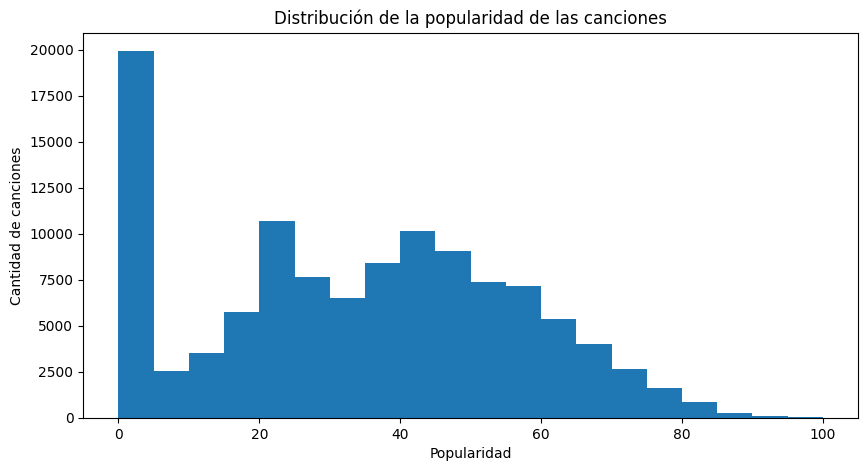

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df['popularity'], bins=20)

plt.title('Distribución de la popularidad de las canciones')
plt.xlabel('Popularidad')
plt.ylabel('Cantidad de canciones')

plt.show()

# 6. Análisis de los géneros musicales

6.1. Cantidad de canciones por género     
Contamos cuántas canciones pertenecen a cada género musical. Esto nos permite conocer la composición del dataset y detectar géneros con mayor o menor representación.

In [131]:
# Cantidad de canciones pertenecientes a cada género
df['track_genre'].value_counts()

,count
track_genre,
acoustic,1000
british,1000
electronic,1000
emo,1000
funk,1000
...,...
honky-tonk,981
dance,965
german,963


In [132]:
# Guardamos la cantidad de canciones por género
genre_counts = df['track_genre'].value_counts()

# Verificamos cuántas canciones contiene cada género
genre_counts.value_counts()

,count
count,
999,36
1000,33
998,21
996,4
993,4
997,3
994,2
991,2
995,1


Luego del tratamiento de los registros duplicados, se observa que la cantidad de canciones por género se mantiene relativamente equilibrada. La mayoría de los géneros conserva alrededor de 1.000 registros, aunque algunos presentan una cantidad menor. En general, no se observa una diferencia extrema en la representación de los géneros, lo que permite realizar comparaciones entre ellos.

# 7. Relación entre características musicales y popularidad


### 7.1 Danceability vs Popularity
Analizamos si existe alguna relación entre el nivel de *danceability* de una canción y su popularidad.

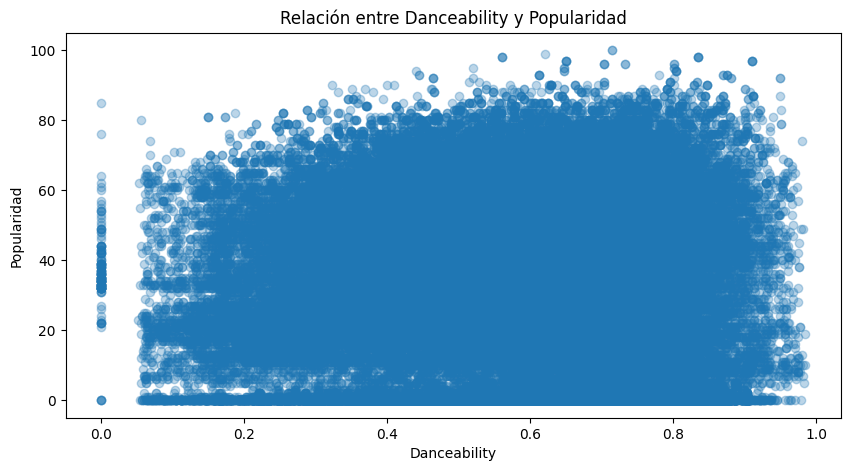

In [133]:
plt.figure(figsize=(10, 5))

plt.scatter(df['danceability'], df['popularity'], alpha=0.3)

plt.title('Relación entre Danceability y Popularidad')
plt.xlabel('Danceability')
plt.ylabel('Popularidad')

plt.show()

### 7.2. Energy vs Popularity     
Analizamos la relación entre la energía de una canción y su nivel de popularidad.

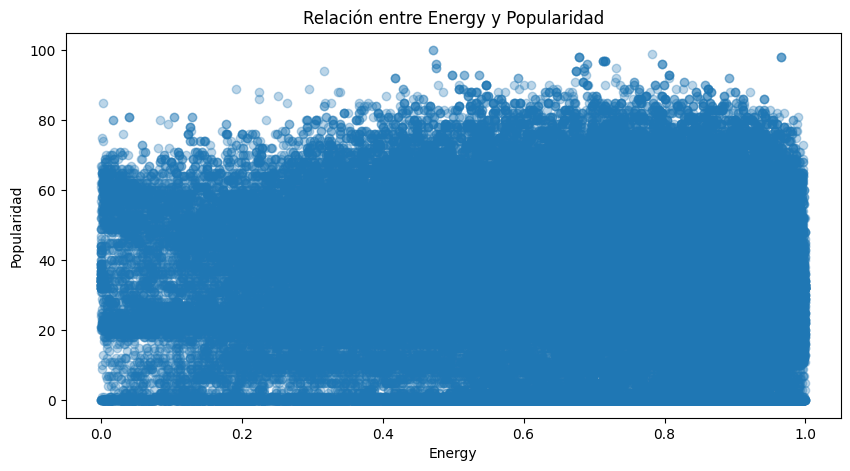

In [134]:
plt.figure(figsize=(10, 5))

plt.scatter(df['energy'], df['popularity'], alpha=0.3)

plt.title('Relación entre Energy y Popularidad')
plt.xlabel('Energy')
plt.ylabel('Popularidad')

plt.show()

### 7.3. Valence vs Popularity                     
Estudiamos si existe una relación entre *valence*, que representa de forma aproximada el carácter positivo o negativo de una canción, y su popularidad.

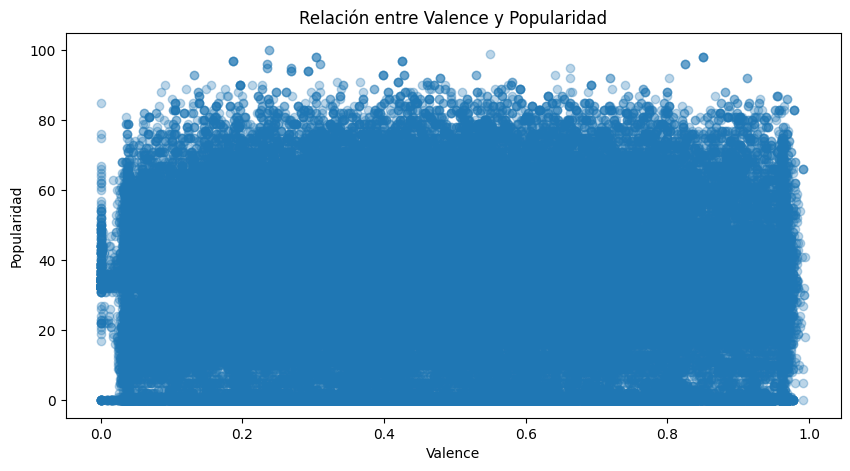

In [135]:
plt.figure(figsize=(10, 5))

plt.scatter(df['valence'], df['popularity'], alpha=0.3)

plt.title('Relación entre Valence y Popularidad')
plt.xlabel('Valence')
plt.ylabel('Popularidad')

plt.show()

# 8. Matriz de correlación
La matriz de correlación permite analizar la relación lineal entre las diferentes variables numéricas del dataset.

In [136]:
# Seleccionamos las variables numéricas
numeric_df = df.select_dtypes(include='number')

# Calculamos la matriz de correlación
correlation_matrix = numeric_df.corr()

correlation_matrix

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.000000,-0.007899,0.034412,-0.002444,-0.004174,0.047371,-0.014991,-0.045459,-0.022370,-0.094711,-0.005658,-0.041109,0.012180,0.030564
duration_ms,-0.007899,1.000000,-0.074108,0.058163,0.008510,-0.004228,-0.035935,-0.063188,-0.103695,0.125307,0.010213,-0.154810,0.024301,0.018347
danceability,0.034412,-0.074108,1.000000,0.131695,0.036544,0.256559,-0.069778,0.108237,-0.169183,-0.183972,-0.131648,0.476750,-0.051518,0.207369
energy,-0.002444,0.058163,0.131695,1.000000,0.048046,0.760624,-0.079328,0.141976,-0.732745,-0.179966,0.184812,0.258448,0.247360,0.186671
key,-0.004174,0.008510,0.036544,0.048046,1.000000,0.038358,-0.135876,0.020819,-0.041119,-0.006821,-0.001521,0.034237,0.010905,0.015123
loudness,0.047371,-0.004228,0.256559,0.760624,0.038358,1.000000,-0.042071,0.060088,-0.588110,-0.432108,0.076793,0.279424,0.212180,0.191648
mode,-0.014991,-0.035935,-0.069778,-0.079328,-0.135876,-0.042071,1.000000,-0.046770,0.096534,-0.050780,0.013909,0.021399,0.000364,-0.024367
speechiness,-0.045459,-0.063188,0.108237,0.141976,0.020819,0.060088,-0.046770,1.000000,-0.001381,-0.089213,0.205092,0.036391,0.017166,-0.000398
acousticness,-0.022370,-0.103695,-0.169183,-0.732745,-0.041119,-0.588110,0.096534,-0.001381,1.000000,0.102129,-0.020321,-0.106228,-0.207613,-0.175618
instrumentalness,-0.094711,0.125307,-0.183972,-0.179966,-0.006821,-0.432108,-0.050780,-0.089213,0.102129,1.000000,-0.079843,-0.324316,-0.049941,-0.081951


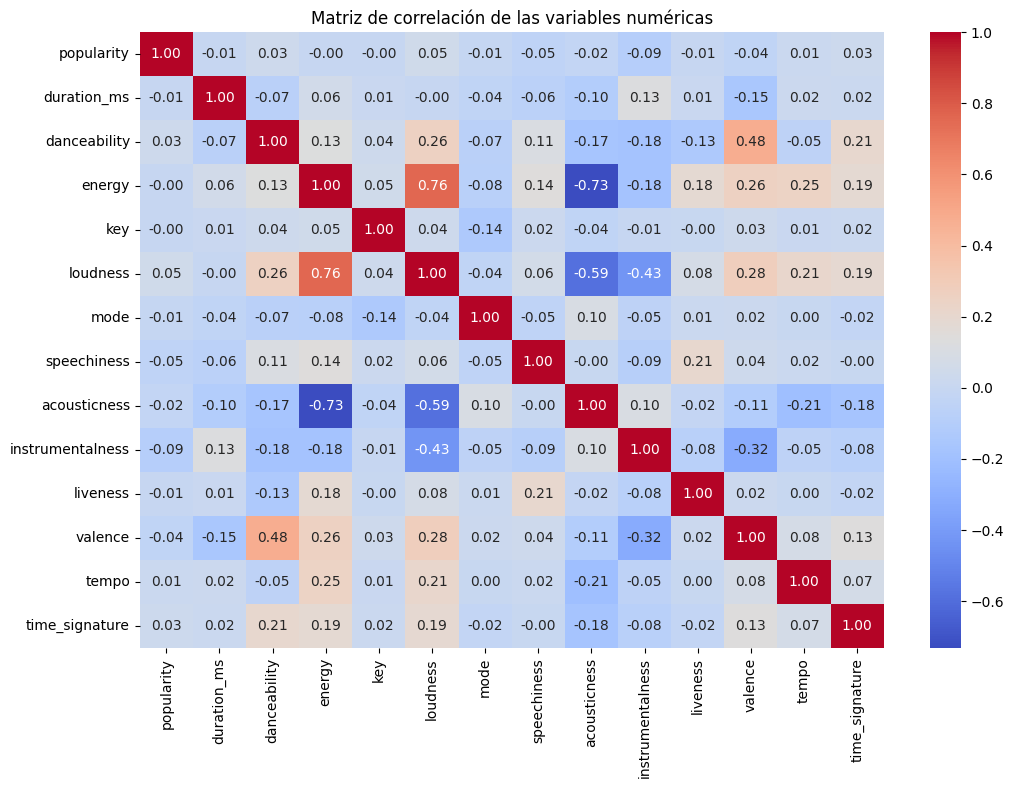

In [137]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación de las variables numéricas')

plt.show()

8.1. El mapa de calor facilita la interpretación de las correlaciones entre las variables. Los valores cercanos a 1 indican una relación positiva fuerte, mientras que los valores cercanos a -1 indican una relación negativa fuerte. Los valores próximos a 0 representan una relación lineal débil.

### 8.2. Interpretación de las correlaciones
*   danceability:
 El gráfico muestra una dispersión amplia de los valores, sin una tendencia lineal claramente definida. Esto coincide con el coeficiente de correlación obtenido entre danceability y popularity, que es aproximadamente 0,035, indicando una relación lineal muy débil entre ambas variables.
*   energy:
 No se observa una relación lineal significativa entre energy y popularity. El coeficiente de correlación es aproximadamente 0,001, lo que indica una relación prácticamente nula en este dataset.
*   valence:
 La relación entre valence y popularity también resulta muy débil. El coeficiente de correlación es aproximadamente -0,041, por lo que no se observa una relación lineal relevante entre ambas variables.

# 9. Transformación de datos
Después de explorar los datos, empezamos a preparar algunas variables para facilitar el análisis.

9.1. Duración de las canciones.                
La variable duration_ms está expresada en milisegundos, por lo que resulta más intuitivo trabajar también con la duración en minutos.   
Creamos una nueva variable llamada duration_min para representar la duración de cada canción en minutos, facilitando su interpretación y visualización.

In [138]:
# Convertimos la duración de milisegundos a minutos
df['duration_min'] = df['duration_ms'] / 60000

In [139]:
df[['duration_ms', 'duration_min']].head()

,duration_ms,duration_min
0,230666,3.844433
1,149610,2.493500
2,210826,3.513767
3,201933,3.365550
4,198853,3.314217


9.2. Categorizar la popularidad        
Transformamos la variable numérica popularity en categorías que permiten analizar las canciones según diferentes niveles de popularidad


In [140]:
# Creamos categorías de popularidad
df['popularity_category'] = pd.cut(
    df['popularity'],
    bins=[-1, 25, 50, 75, 100],
    labels=['Baja', 'Media-Baja', 'Media-Alta', 'Alta']
)

In [141]:
# Calculamos el porcentaje de canciones en cada categoría
df['popularity_category'].value_counts(normalize=True).mul(100).round(2)

,proportion
popularity_category,
Baja,38.79
Media-Baja,36.78
Media-Alta,22.31
Alta,2.12


9.3 Se observa una concentración de canciones en los niveles de popularidad bajos y medios, mientras que una proporción mucho menor alcanza niveles de popularidad altos. Esto indica que la variable popularity no se encuentra distribuida de manera uniforme.

9.4. Observamos cuántas canciones hay en cada categoría:

In [142]:
df['popularity_category'].value_counts()

,count
popularity_category,
Baja,44042
Media-Baja,41759
Media-Alta,25337
Alta,2412


9.5 Popularidad promedio por género

In [143]:
popularidad_genero = (
    df.groupby('track_genre')['popularity']
    .mean()
    .sort_values(ascending=False)
)

popularidad_genero.head(10)

,popularity
track_genre,
pop-film,59.280280
k-pop,56.906907
chill,53.704705
sad,52.379000
grunge,49.582583
indian,49.528529
anime,48.766767
emo,48.128000
pop,47.903323


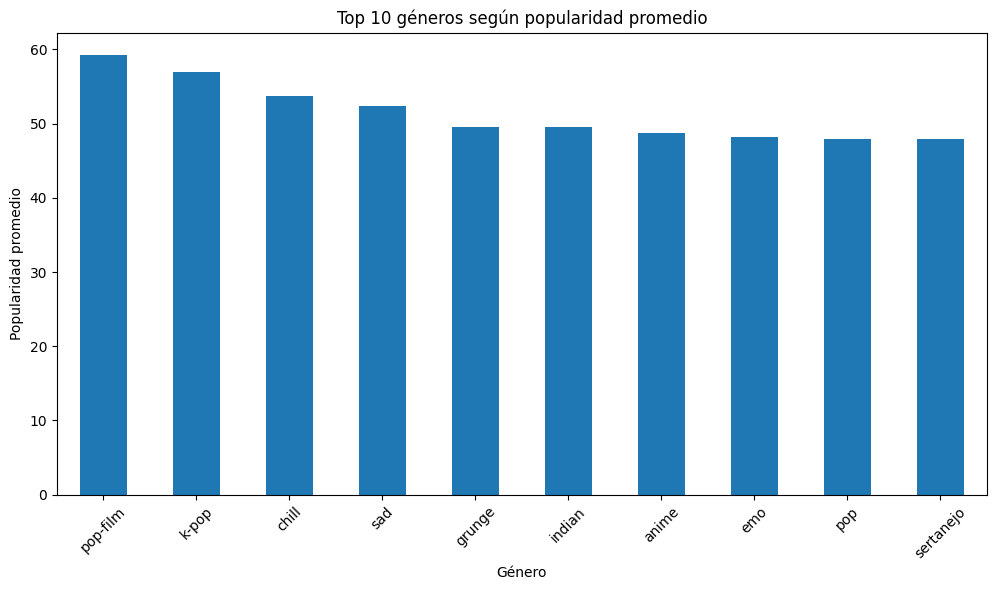

In [144]:
plt.figure(figsize=(12, 6))

popularidad_genero.head(10).plot(kind='bar')

plt.title('Top 10 géneros según popularidad promedio')
plt.xlabel('Género')
plt.ylabel('Popularidad promedio')
plt.xticks(rotation=45)

plt.show()

9.6 Correlación de todas las variables con Popularity         
Muestra qué variables están más relacionadas con la popularidad.

In [145]:
# Correlación de las variables numéricas con la popularidad
correlation_matrix['popularity'].sort_values(ascending=False)

,popularity
popularity,1.000000
loudness,0.047371
danceability,0.034412
time_signature,0.030564
tempo,0.012180
energy,-0.002444
key,-0.004174
liveness,-0.005658
duration_ms,-0.007899
mode,-0.014991


Las correlaciones con popularity son bajas en todas las variables analizadas. La mayor correlación positiva corresponde a loudness (0,047), mientras que la mayor correlación negativa corresponde a instrumentalness (-0,094). En ambos casos, la relación lineal es débil, por lo que ninguna de estas características presenta por sí sola una relación fuerte con la popularidad.

# 10. Conclusiones

A partir del Análisis Exploratorio de Datos realizado sobre el dataset de canciones de Spotify, se pudo conocer su estructura, composición y principales características.

En primer lugar, se identificaron valores faltantes en las variables `artists`, `album_name` y `track_name`, los cuales fueron tratados reemplazándolos por la categoría `"Desconocido"`. También se detectaron registros duplicados, que fueron eliminados para evitar que afectaran los análisis posteriores.

Respecto de los géneros musicales, se observó una distribución equilibrada en la cantidad de canciones por género, sin una marcada sobrerrepresentación de determinadas categorías. Esto permite realizar comparaciones entre los distintos géneros con una distribución relativamente uniforme de los datos.

El análisis de la variable `popularity` mostró una mayor concentración de canciones en niveles de popularidad bajos y medios, mientras que las canciones con niveles de popularidad altos representan una proporción menor del dataset.

Por otro lado, el análisis de correlaciones permitió observar que características musicales como `danceability`, `energy` y `valence` presentan una relación lineal muy débil con la popularidad. Esto indica que la popularidad de una canción no parece estar explicada de manera significativa por una única característica musical.

Finalmente, se realizaron transformaciones de datos, como la conversión de la duración de milisegundos a minutos y la categorización de la popularidad, con el objetivo de facilitar la interpretación y los análisis posteriores.

En conclusión, el EDA permitió identificar las principales características del dataset, detectar y tratar problemas de calidad de los datos y encontrar relaciones relevantes entre las variables. Estos resultados servirán como base para las próximas etapas del proyecto, en las que se podrá avanzar hacia la selección de variables y la construcción de modelos predictivos orientados al análisis de la popularidad de las canciones.